# Explorar datos con Python — datos del mundo real

En este cuaderno explorarás distribuciones de datos no normales y cómo hacer comparaciones básicas entre datos.

## Cargar los datos

Antes vimos las calificaciones de nuestros estudiantes y estimamos, a partir de esa muestra, cómo podría verse la población completa de calificaciones. Refresquemos la memoria y volvamos a ver esos datos.

Ejecuta la siguiente celda para cargar los datos (`../datasets/grades.csv`) y generar un histograma junto con un diagrama de caja que muestren las calificaciones de nuestra muestra de estudiantes.

         Name  StudyHours  Grade   Pass
0         Dan       10.00   50.0  False
1       Joann       11.50   50.0  False
2       Pedro        9.00   47.0  False
3       Rosie       16.00   97.0   True
4       Ethan        9.25   49.0  False
5       Vicky        1.00    3.0  False
6    Frederic       11.50   53.0  False
7      Jimmie        9.00   42.0  False
8      Rhonda        8.50   26.0  False
9    Giovanni       14.50   74.0   True
10  Francesca       15.50   82.0   True
11      Rajab       13.75   62.0   True
12    Naiyana        9.00   37.0  False
13       Kian        8.00   15.0  False
14      Jenny       15.50   70.0   True
15     Jakeem        8.00   27.0  False
16     Helena        9.00   36.0  False
17      Ismat        6.00   35.0  False
18      Anila       10.00   48.0  False
19       Skye       12.00   52.0  False
20     Daniel       12.50   63.0   True
21      Aisha       12.00   64.0   True
Mínimo:3.00
Media:49.18
Mediana:49.50
Moda:50.00
Máximo:97.00



C:\Users\migue\AppData\Local\Temp\ipykernel_36540\3350853203.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


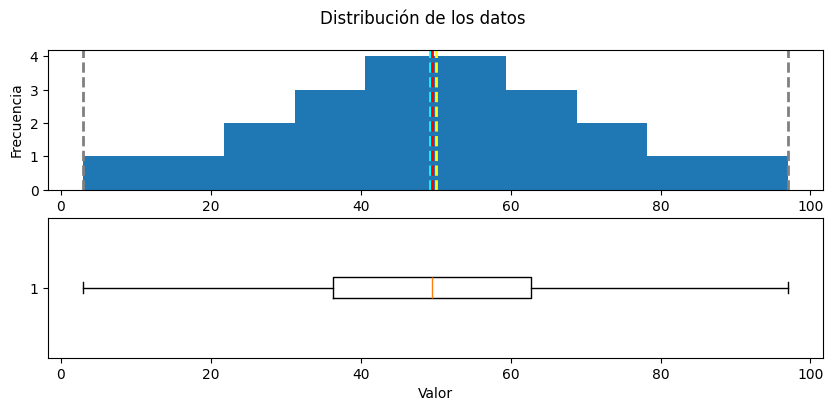

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

# Cargar los datos desde un archivo de texto
df_students = pd.read_csv('../datasets/grades.csv',delimiter=',',header='infer')

# Eliminar las filas con datos faltantes
df_students = df_students.dropna(axis=0, how='any')

# Calcular quién aprobó, asumiendo que '60' es la calificación mínima para aprobar
passes  = pd.Series(df_students['Grade'] >= 60)

# Guardar el resultado en el DataFrame de Pandas
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)


# Imprimir el resultado en este cuaderno
print(df_students)


# Crear una función que podamos reutilizar
def mostrar_distribucion(var_data):
    '''
    Esta función crea un gráfico de distribución y lo muestra
    '''

    # Obtener las estadísticas
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Mínimo:{:.2f}\nMedia:{:.2f}\nMediana:{:.2f}\nModa:{:.2f}\nMáximo:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Crear una figura para 2 subgráficos (2 filas, 1 columna)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Graficar el histograma
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frecuencia')

    # Agregar líneas para la media, mediana y moda
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Graficar el diagrama de caja
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Valor')

    # Agregar un título a la figura
    fig.suptitle('Distribución de los datos')

    # Mostrar la figura
    fig.show()


mostrar_distribucion(df_students['Grade'])

Como recordarás, en estos datos la media y la moda estaban en el centro, con los datos repartidos simétricamente desde ahí.

Ahora veamos la distribución de los datos de horas de estudio.

Mínimo:1.00
Media:10.52
Mediana:10.00
Moda:9.00
Máximo:16.00



C:\Users\migue\AppData\Local\Temp\ipykernel_36540\3350853203.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


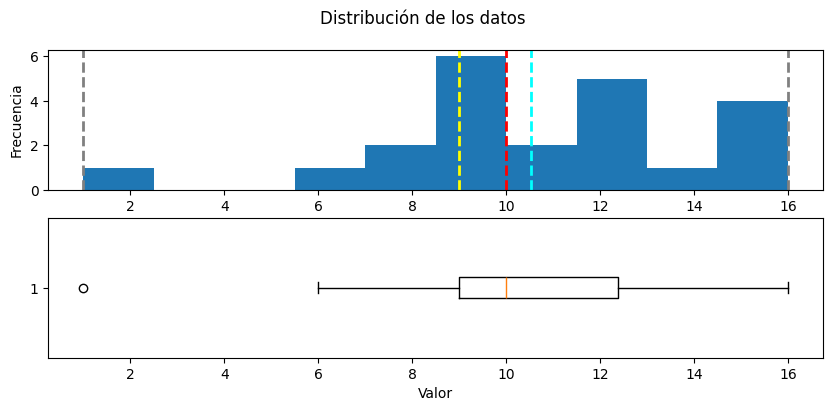

In [ ]:
# Obtener la variable a examinar
col = df_students['StudyHours']
# Llamar a la función
mostrar_distribucion(col)

La distribución de los datos de tiempo de estudio es notablemente distinta a la de las calificaciones.

Fíjate que los bigotes del diagrama de caja empiezan alrededor de 6.0, lo que indica que la gran mayoría del primer cuarto de los datos está por encima de ese valor. El mínimo está marcado con una **o**, lo que indica que estadísticamente es un *valor atípico*: un valor que queda significativamente fuera del rango del resto de la distribución.

Los valores atípicos pueden ocurrir por muchas razones. Tal vez un estudiante quiso registrar "10" horas de estudio, pero escribió "1" y se le olvidó el "0". O tal vez el estudiante fue anormalmente perezoso para estudiar. De cualquier forma, es una anomalía estadística que no representa a un estudiante típico. Veamos cómo se ve la distribución sin ese valor.

In [ ]:
# Obtener la variable a examinar
# Solo tomaremos los estudiantes que estudiaron más de una hora
col = df_students[df_students.StudyHours>1]['StudyHours']

# Llamar a la función
mostrar_distribucion(col)

Con fines de aprendizaje, aquí tratamos el valor **1** como un verdadero valor atípico y lo excluimos. En el mundo real, sería inusual excluir datos en los extremos sin más justificación cuando el tamaño de la muestra es tan pequeño. Esto se debe a que, cuanto más pequeño es el tamaño de la muestra, más probable es que nuestro muestreo sea una mala representación de toda la población. (Aquí, la población son las calificaciones de todos los estudiantes, no solo nuestros 22.) Por ejemplo, si tomáramos una muestra del tiempo de estudio de otros 1000 estudiantes, ¡podríamos encontrar que en realidad es bastante común no estudiar mucho!

Cuando disponemos de más datos, nuestra muestra se vuelve más confiable. Esto facilita considerar como valores atípicos aquellos que caen por debajo o por encima de ciertos percentiles dentro de los cuales está la mayoría de los datos. Por ejemplo, el siguiente código usa la función **quantile** de Pandas para excluir observaciones por debajo del percentil 0.01 (el valor por encima del cual está el 99% de los datos).

In [ ]:
# Calcular el percentil 0.01
q01 = df_students.StudyHours.quantile(0.01)
# Obtener la variable a examinar
col = df_students[df_students.StudyHours>q01]['StudyHours']
# Llamar a la función
mostrar_distribucion(col)

> **Consejo**: También puedes eliminar valores atípicos en el extremo superior de la distribución definiendo un umbral en un percentil alto. Por ejemplo, podrías usar la función **quantile** para encontrar el percentil 0.99, por debajo del cual está el 99% de los datos.

Con los valores atípicos eliminados, el diagrama de caja muestra todos los datos dentro de los cuatro cuartiles. Fíjate que la distribución no es simétrica como en el caso de las calificaciones. Hay algunos estudiantes con tiempos de estudio muy altos, de alrededor de 16 horas, pero el grueso de los datos está entre 7 y 13 horas. Los pocos valores extremadamente altos jalan la media hacia el extremo superior de la escala.

Veamos la densidad de esta distribución.

In [ ]:
def mostrar_densidad(var_data):
    fig = plt.figure(figsize=(10,4))

    # Graficar la densidad
    var_data.plot.density()

    # Agregar títulos y etiquetas
    plt.title('Densidad de los datos')

    # Mostrar la media, mediana y moda
    plt.axvline(x=var_data.mean(), color = 'cyan', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.median(), color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.mode()[0], color = 'yellow', linestyle='dashed', linewidth = 2)

    # Mostrar la figura
    plt.show()

# Obtener la densidad de StudyHours
mostrar_densidad(col)

Este tipo de distribución se llama *sesgada a la derecha* (right skewed). El grueso de los datos está en el lado izquierdo de la distribución, formando una cola larga hacia la derecha por los valores en el extremo superior, que jalan la media hacia la derecha.

**Medidas de variabilidad**

Ya tenemos una buena idea de dónde está el centro de las distribuciones de calificaciones y horas de estudio. Sin embargo, hay otro aspecto de las distribuciones que deberíamos examinar: ¿cuánta variabilidad hay en los datos?

Las estadísticas típicas que miden la variabilidad de los datos incluyen:

- **Rango**: la diferencia entre el máximo y el mínimo. No hay una función incorporada para esto, pero es fácil de calcular con las funciones **min** y **max**.
- **Varianza**: el promedio de la diferencia al cuadrado respecto a la media. Puedes usar la función incorporada **var** para calcularla.
- **Desviación estándar**: la raíz cuadrada de la varianza. Puedes usar la función incorporada **std** para calcularla.

In [ ]:
for col_name in ['Grade','StudyHours']:
    col = df_students[col_name]
    rng = col.max() - col.min()
    var = col.var()
    std = col.std()
    print('\n{}:\n - Rango: {:.2f}\n - Varianza: {:.2f}\n - Desv. Estándar: {:.2f}'.format(col_name, rng, var, std))

De estas estadísticas, la desviación estándar suele ser la más útil. Da una medida de la variabilidad de los datos en la misma escala que los datos mismos (así que puntos de calificación para la distribución de Grade, y horas para la de StudyHours). Cuanto mayor sea la desviación estándar, mayor es la variabilidad al comparar valores de la distribución con la media de la distribución; en otras palabras, los datos están más dispersos.

Cuando trabajamos con una distribución *normal*, la desviación estándar aprovecha las características particulares de la distribución normal para dar información aún más valiosa. Ejecuta la siguiente celda para ver la relación entre las desviaciones estándar y los datos en la distribución normal.

In [ ]:
import scipy.stats as stats

# Obtener la columna Grade
col = df_students['Grade']

# Obtener la densidad
density = stats.gaussian_kde(col)

# Graficar la densidad
col.plot.density()

# Obtener la media y la desviación estándar
s = col.std()
m = col.mean()

# Marcar 1 desviación estándar
x1 = [m-s, m+s]
y1 = density(x1)
plt.plot(x1,y1, color='magenta')
plt.annotate('1 desv. est. (68.26%)', (x1[1],y1[1]))

# Marcar 2 desviaciones estándar
x2 = [m-(s*2), m+(s*2)]
y2 = density(x2)
plt.plot(x2,y2, color='green')
plt.annotate('2 desv. est. (95.45%)', (x2[1],y2[1]))

# Marcar 3 desviaciones estándar
x3 = [m-(s*3), m+(s*3)]
y3 = density(x3)
plt.plot(x3,y3, color='orange')
plt.annotate('3 desv. est. (99.73%)', (x3[1],y3[1]))

# Mostrar la ubicación de la media
plt.axvline(col.mean(), color='cyan', linestyle='dashed', linewidth=1)

plt.axis('off')

plt.show()

Las líneas horizontales muestran el porcentaje de datos dentro de una, dos y tres desviaciones estándar de la media (en más o en menos).

En cualquier distribución normal:
- Aproximadamente el 68.26% de los valores caen dentro de una desviación estándar de la media.
- Aproximadamente el 95.45% de los valores caen dentro de dos desviaciones estándar de la media.
- Aproximadamente el 99.73% de los valores caen dentro de tres desviaciones estándar de la media.

Entonces, como sabemos que la calificación media es 49.18, la desviación estándar es 21.74, y la distribución de calificaciones es aproximadamente normal, podemos calcular que el 68.26% de los estudiantes debería obtener una calificación entre 27.44 y 70.92.

Las estadísticas descriptivas que usamos para entender la distribución de las variables de los estudiantes son la base del análisis estadístico. Como son una parte tan importante de la exploración de datos, el objeto DataFrame tiene un método incorporado `describe` que devuelve las principales estadísticas descriptivas de todas las columnas numéricas.

In [ ]:
print(df_students.describe())

## Comparar datos

Ahora que sabes algo sobre la distribución estadística de los datos de tu dataset, estás listo para examinarlos en busca de relaciones aparentes entre variables.

Primero, quitemos las filas que contienen valores atípicos para tener una muestra representativa de una clase típica de estudiantes. Ya identificamos que la columna StudyHours tiene valores atípicos con valores extremadamente bajos, así que eliminaremos esas filas.

In [ ]:
df_sample = df_students[df_students['StudyHours']>1]
print(df_sample)

### Comparar variables numéricas y categóricas

Los datos incluyen dos variables *numéricas* (**StudyHours** y **Grade**) y dos variables *categóricas* (**Name** y **Pass**). Empecemos comparando la columna numérica **StudyHours** con la columna categórica **Pass** para ver si hay una relación aparente entre las horas de estudio y aprobar la materia.

Para hacer esta comparación, creemos diagramas de caja que muestren la distribución de StudyHours para cada valor posible de Pass (verdadero y falso).

In [ ]:
df_sample.boxplot(column='StudyHours', by='Pass', figsize=(8,5))

Comparando las distribuciones de StudyHours, es evidente (aunque no particularmente sorprendente) que los estudiantes que aprobaron el curso tendieron a estudiar más horas que los que no aprobaron. Así que si quisieras predecir si un estudiante va a aprobar el curso, la cantidad de tiempo que dedica a estudiar podría ser un buen indicador predictivo.

### Comparar variables numéricas

Ahora comparemos dos variables numéricas. Empecemos creando un gráfico de barras que muestre tanto la calificación como las horas de estudio.

In [ ]:
# Crear un gráfico de barras de nombre vs calificación y horas de estudio
df_sample.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

El gráfico muestra barras tanto para la calificación como para las horas de estudio de cada estudiante, pero no es fácil compararlas porque los valores están en escalas distintas. Una calificación se mide en puntos (y va de 3 a 97), y el tiempo de estudio se mide en horas (y va de 1 a 16).

Una técnica común al trabajar con datos numéricos en escalas distintas es *normalizar* los datos, para que conserven su distribución proporcional pero queden medidos en la misma escala. Para lograrlo, usaremos una técnica llamada escalado *MinMax*, que distribuye los valores proporcionalmente en una escala de 0 a 1. Podrías escribir el código para aplicar esta transformación tú mismo, pero la biblioteca **Scikit-Learn** ya trae un escalador que lo hace por ti.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Obtener un objeto escalador
scaler = MinMaxScaler()

# Crear un nuevo DataFrame para los valores escalados
df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()

# Normalizar las columnas numéricas
df_normalized[['Grade','StudyHours']] = scaler.fit_transform(df_normalized[['Grade','StudyHours']])

# Graficar los valores normalizados
df_normalized.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

Con los datos normalizados, es más fácil ver una relación aparente entre calificación y tiempo de estudio. No es una coincidencia exacta, pero definitivamente parece que los estudiantes con calificaciones más altas tienden a haber estudiado más.

Así que parece haber una correlación entre el tiempo de estudio y la calificación. De hecho, existe una medida estadística de *correlación* que podemos usar para cuantificar la relación entre estas columnas.

In [ ]:
print(df_normalized.Grade.corr(df_normalized.StudyHours))

El estadístico de correlación es un valor entre -1 y 1 que indica la fuerza de una relación. Valores por encima de 0 indican una correlación *positiva* (valores altos de una variable tienden a coincidir con valores altos de la otra), mientras que valores por debajo de 0 indican una correlación *negativa* (valores altos de una variable tienden a coincidir con valores bajos de la otra). En este caso, el valor de correlación está cerca de 1, lo que muestra una correlación fuertemente positiva entre el tiempo de estudio y la calificación.

> **Nota**: Los científicos de datos suelen citar la máxima "*correlación* no es *causalidad*". Es decir, por más tentador que sea, no deberías interpretar la correlación estadística como una explicación de *por qué* uno de los valores es alto. En el caso de los datos de los estudiantes, las estadísticas demuestran que los estudiantes con calificaciones altas también tienden a tener cantidades altas de tiempo de estudio, pero eso no es lo mismo que demostrar que obtuvieron calificaciones altas *porque* estudiaron mucho. Con el mismo estadístico podrías igualmente sostener la conclusión absurda de que los estudiantes estudiaron mucho *porque* sus calificaciones iban a ser altas.

Otra forma de visualizar la aparente correlación entre dos columnas numéricas es usando un diagrama de *dispersión*.

In [ ]:
# Crear un diagrama de dispersión
df_sample.plot.scatter(title='Tiempo de estudio vs Calificación', x='StudyHours', y='Grade')

De nuevo, parece haber un patrón perceptible en el que los estudiantes que estudiaron más horas también son los que obtuvieron las calificaciones más altas.

Podemos verlo con más claridad agregando una línea de *regresión* (o *línea de mejor ajuste*) al gráfico, que muestra la tendencia general de los datos. Para esto, usaremos una técnica estadística llamada *regresión por mínimos cuadrados*.

Recuerda cuando aprendiste a resolver ecuaciones lineales en la escuela: la forma *pendiente-intersección* de una ecuación lineal se ve así:

*y = mx + b*

En esta ecuación, *y* y *x* son las variables de coordenadas, *m* es la pendiente de la línea, y *b* es el punto donde la línea corta el eje Y (intersección).

En el caso de nuestro diagrama de dispersión de los datos de los estudiantes, ya tenemos los valores de *x* (*StudyHours*) y *y* (*Grade*), así que solo necesitamos calcular la intersección y la pendiente de la línea recta que queda más cerca de esos puntos. Luego podemos formar una ecuación lineal que calcule un nuevo valor de *y* sobre esa línea para cada valor de *x* (*StudyHours*). Para evitar confusiones, llamaremos a este nuevo valor de *y* como *f(x)* (porque es el resultado de una ***f***unción lineal basada en *x*). La diferencia entre el valor original de *y* (*Grade*) y el valor de *f(x)* es el *error* entre nuestra línea de regresión y la calificación real obtenida por el estudiante. Nuestro objetivo es calcular la pendiente y la intersección de la línea con el menor error total posible.

En concreto, definimos el error total tomando el error de cada punto, elevándolo al cuadrado, y sumando todos los errores al cuadrado. La línea de mejor ajuste es la que da el menor valor para la suma de los errores al cuadrado, de ahí el nombre *regresión por mínimos cuadrados*.

Por suerte, no necesitas programar tú mismo el cálculo de la regresión. El paquete **SciPy** incluye una clase **stats** que ofrece un método **linregress** que hace el trabajo pesado por ti. Este devuelve (entre otras cosas) los coeficientes que necesitas para la ecuación de la recta: la pendiente (*m*) y la intersección (*b*) a partir de un par de variables de muestra que quieras comparar.

In [ ]:
from scipy import stats

#
df_regression = df_sample[['Grade', 'StudyHours']].copy()

# Obtener la pendiente e intersección de la regresión
m, b, r, p, se = stats.linregress(df_regression['StudyHours'], df_regression['Grade'])
print('pendiente: {:.4f}\nintersección en y: {:.4f}'.format(m,b))
print('entonces...\n f(x) = {:.4f}x + {:.4f}'.format(m,b))

# Usar la función (mx + b) para calcular f(x) para cada valor de x (StudyHours)
df_regression['fx'] = (m * df_regression['StudyHours']) + b

# Calcular el error entre f(x) y el valor real de y (Grade)
df_regression['error'] = df_regression['fx'] - df_regression['Grade']

# Crear un diagrama de dispersión de Grade vs StudyHours
df_regression.plot.scatter(x='StudyHours', y='Grade')

# Graficar la línea de regresión
plt.plot(df_regression['StudyHours'],df_regression['fx'], color='cyan')

# Mostrar el gráfico
plt.show()

Fíjate que esta vez el código graficó dos cosas distintas: el diagrama de dispersión de la muestra de horas de estudio y calificaciones, como antes, y además una línea de mejor ajuste basada en los coeficientes de la regresión por mínimos cuadrados.

Los coeficientes de pendiente e intersección calculados para la línea de regresión se muestran arriba del gráfico.

La línea se basa en los valores de ***f*(x)** calculados para cada valor de **StudyHours**. Ejecuta la siguiente celda para ver una tabla que incluye:

- Las **StudyHours** de cada estudiante.
- La **Grade** obtenida por cada estudiante.
- El valor de ***f(x)*** calculado con los coeficientes de la línea de regresión.
- El *error* entre el valor calculado de ***f(x)*** y el valor real de **Grade**.

Algunos de los errores, sobre todo en los extremos, son bastante grandes (de más de 17.5 puntos de calificación). Pero, en general, la línea queda bastante cerca de las calificaciones reales.

In [ ]:
# Mostrar los valores originales de x,y, el valor de f(x), y el error
print(df_regression[['StudyHours', 'Grade', 'fx', 'error']])

### Usar los coeficientes de la regresión para predecir

Ahora que tienes los coeficientes de regresión para la relación entre tiempo de estudio y calificación, puedes usarlos en una función para estimar la calificación esperada dado cierto tiempo de estudio.

In [ ]:
# Definir una función basada en nuestros coeficientes de regresión
def f(x):
    m = 6.3134
    b = -17.9164
    return m*x + b

tiempo_estudio = 14

# Obtener f(x) para el tiempo de estudio
prediccion = f(tiempo_estudio)

# La calificación no puede ser menor que 0 ni mayor que 100
calificacion_esperada = max(0,min(100,prediccion))

# Imprimir la calificación estimada
print ('Estudiar {} horas por semana podría resultar en una calificación de {:.0f}'.format(tiempo_estudio, calificacion_esperada))

Así, aplicando estadística a los datos de una muestra, determinaste una relación entre el tiempo de estudio y la calificación, y la encapsulaste en una función general que puede usarse para predecir una calificación dado cierto tiempo de estudio.

Esta técnica es, de hecho, la premisa básica del Machine Learning. Puedes tomar un conjunto de datos de muestra que incluya una o más *features* (en este caso, el número de horas estudiadas) y un valor de *label* conocido (en este caso, la calificación obtenida), y usar esos datos de muestra para derivar una función que calcule valores de label predichos para cualquier conjunto dado de features.

## Resumen

Aquí vimos:

1. Qué es un valor atípico y cómo eliminarlo.
2. Cómo pueden sesgarse los datos.
3. Cómo ver la dispersión de los datos.
4. Formas básicas de comparar variables, como calificaciones y tiempo de estudio.